In [1]:
import os
import operator
from difflib import SequenceMatcher
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool
from langchain_core.messages import (
    AnyMessage, HumanMessage, SystemMessage, ToolMessage,
    RemoveMessage,
)

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, REMOVE_ALL_MESSAGES
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

from ddgs import DDGS

load_dotenv()

True

In [2]:
# ======================================================================
# 1. MODELLE
# ======================================================================

llm_supervisor = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)
llm_researcher = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)
llm_analyst    = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.2)
llm_writer     = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.7)
llm_critic     = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)

In [3]:
# ======================================================================
# 2. TOOL
# ======================================================================

@tool
def web_suche(query: str) -> str:
    """Sucht im Web nach aktuellen Informationen zu einer Anfrage.
    Nutze dies, wenn du Informationen brauchst, die du nicht sicher weisst
    oder die aktuell/2026 sein koennte.

    Args:
        query: Die Suchanfrage, z.B. "Schwingfest 2026 Termine Schweiz"
    """
    with DDGS() as ddgs:
        ergebnisse = list(ddgs.text(query, max_results=4))
    if not ergebnisse:
        return "Keine Ergebnisse gefunden."
    return "\n\n".join(
        f"Titel: {r['title']}\nURL: {r['href']}\nAuszug: {r['body']}"
        for r in ergebnisse
    )

tools = [web_suche]
llm_researcher_mit_tools = llm_researcher.bind_tools(tools)
node_tools = ToolNode(tools)

In [4]:
# ======================================================================
# 3. STRUKTURIERTER OUTPUT
# ======================================================================

class BranchEntscheidung(BaseModel):
    next: Literal["researcher", "writer", "eskalation"] = Field(
        description="researcher wenn Fakten/Daten/Zahlen/Quellen fehlen, "
        "writer wenn nur Formulierung/Struktur/Laenge betroffen ist, "
        "eskalation wenn keiner der beiden sinnvoll ist."
    )

llm_branch_structured = llm_supervisor.with_structured_output(BranchEntscheidung)

BRANCH_SYSTEM = """Du entscheidest NUR eine Sache: ob nach negativem Feedback
der researcher oder der writer erneut arbeiten soll.

Regeln:
1. Waehle "researcher", wenn dem Bericht faktische Informationen, Daten,
   Zahlen oder Quellen fehlen.
2. Waehle "writer", wenn die vorhandenen Informationen ausreichen, aber
   Formulierung, Struktur oder Laenge mangelhaft sind.
3. Waehle "eskalation" nur, wenn das Feedback keinem der beiden Faelle
   eindeutig zugeordnet werden kann.
Antworte NUR mit dem Feld next."""


class CriticBewertung(BaseModel):
    ausreichend: bool = Field(
        description="True wenn ALLE Kriterien erfuellt sind: "
        "(1) mind. 3 konkrete Zahlen/Statistiken, "
        "(2) max. 300 Woerter, "
        "(3) mind. 2 verschiedene Perspektiven/Aspekte abgedeckt."
    )
    grund: Literal["daten", "formulierung", "keine"] = Field(
        description="Bei ausreichend=False: 'daten' wenn Fakten/Zahlen/Quellen "
        "fehlen, 'formulierung' wenn nur Sprache/Struktur/Laenge betroffen ist. "
        "Bei ausreichend=True: 'keine'."
    )
    feedback: str = Field(
        description="Falls ausreichend=False: konkretes Feedback was fehlt oder "
        "verbessert werden muss. Falls ausreichend=True: leerer String."
    )

llm_critic_structured = llm_critic.with_structured_output(CriticBewertung)

In [5]:
# ======================================================================
# 4. DER STATE
# ======================================================================

MAX_RETRIES = 2      # harte Obergrenze pro Worker
MAX_ZYKLEN = 8       # harte globale Obergrenze ueber alle Schritte

class SupervisorState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    thema: str
    next: str
    instruction: str
    #recherche: str
    recherche: Annotated[list[str], operator.add]
    analyse: str
    bericht: str
    verlauf: Annotated[list[str], operator.add]
    critic_ausreichend: bool
    critic_feedback: str
    critic_grund: str
    freigabe_feedback: str
    researcher_retries: int
    writer_retries: int
    last_critic_feedback: str
    last_freigabe_feedback: str
    zyklus_count: int
    log: Annotated[list[dict], operator.add] # Reines Analyse-Log, wird nie an LLMs uebergeben

In [6]:
# ======================================================================
# 5. NODES
# ======================================================================

def _feedback_aehnlich(a: str, b: str) -> bool:
    """Erkennt, ob sich Feedback zwischen zwei Runden kaum
    veraendert hat -> starkes Signal fuer eine Endlosschleife trotz
    Ueberarbeitung."""
    if not a or not b:
        return False
    return SequenceMatcher(None, a, b).ratio() > 0.85


def _entscheide_branch(state: SupervisorState, quelle: str) -> tuple[str, str, dict]:
    """Gekapselte Funktion fuer die zwei einzigen echten
    inhaltlichen Entscheidungen des Supervisors (Regel 5 und 8).
    Gibt (next_worker, instruction, extra_state_updates) zurueck."""

    zyklus_count = state.get("zyklus_count", 0)
    
    aktuelles_feedback = (
        state.get("critic_feedback", "") if quelle == "critic"
        else state.get("freigabe_feedback", "")
    )
    letztes_feedback = (
        state.get("last_critic_feedback", "") if quelle == "critic"
        else state.get("last_freigabe_feedback", "")
    )
    researcher_retries = state.get("researcher_retries", 0)
    writer_retries = state.get("writer_retries", 0)
    researcher_verfuegbar = researcher_retries < MAX_RETRIES
    writer_verfuegbar = writer_retries < MAX_RETRIES

    extra: dict = {
        "last_critic_feedback": state.get("last_critic_feedback", ""),
        "last_freigabe_feedback": state.get("last_freigabe_feedback", ""),
    }
    if quelle == "critic":
        extra["last_critic_feedback"] = aktuelles_feedback
    else:
        extra["last_freigabe_feedback"] = aktuelles_feedback

    if zyklus_count >= MAX_ZYKLEN:
        print(f"[Supervisor] Retry-Runden-Limit ({MAX_ZYKLEN}) erreicht "
              f"-> Eskalation.")
        return "FINISH", "Eskalation: maximale Anzahl an Ueberarbeitungsrunden erreicht.", extra
    
    # Ähnlichkeits-Check -> Eskalation statt weiterer Iteration
    if _feedback_aehnlich(aktuelles_feedback, letztes_feedback):
        print(f"[Supervisor] Feedback von '{quelle}' aehnelt dem "
              f"vorherigen -> Eskalation statt weiterer Iteration.")
        return "FINISH", f"Eskalation: wiederholtes Feedback von {quelle} ohne erkennbare Verbesserung.", extra

    # harte Retry-Limits im Code, unabhaengig von jeder LLM-Entscheidung
    if not researcher_verfuegbar and not writer_verfuegbar:
        print("[Supervisor] Retry-Limits fuer researcher UND writer "
              "erschoepft -> Eskalation.")
        return "FINISH", "Eskalation: Retry-Limits erschoepft.", extra

    if quelle == "critic" and state.get("critic_grund") in ("daten", "formulierung"):
        # direktes Mapping aus dem strukturierten Critic-Feld,
        # kein zusaetzlicher LLM-Call noetig (zuverlaessiger als Freitext-Interpretation)
        next_worker = "researcher" if state["critic_grund"] == "daten" else "writer"
    else:
        # freigabe liefert Freitext eines Menschen -> das kann nur ein LLM klassifizieren.
        # strukturierte, vorberechnete Kennzahlen statt Rohtext-Historie
        kontext = (
            f"Feedback von {quelle}: {aktuelles_feedback}\n\n"
            f"Verbleibende researcher-Versuche: {max(0, MAX_RETRIES - researcher_retries)}\n"
            f"Verbleibende writer-Versuche: {max(0, MAX_RETRIES - writer_retries)}\n"
        )
        entscheidung = llm_branch_structured.invoke([
            SystemMessage(content=BRANCH_SYSTEM),
            HumanMessage(content=kontext),
        ])
        next_worker = entscheidung.next

    # Retry-Limit im Code erzwingen, auch wenn grund/LLM anders entscheidet
    if next_worker == "researcher" and not researcher_verfuegbar:
        next_worker = "writer" if writer_verfuegbar else "FINISH"
    if next_worker == "writer" and not writer_verfuegbar:
        next_worker = "researcher" if researcher_verfuegbar else "FINISH"
    if next_worker == "eskalation":
        next_worker = "FINISH"

    if next_worker == "researcher":
        extra["researcher_retries"] = researcher_retries + 1
    elif next_worker == "writer":
        extra["writer_retries"] = writer_retries + 1

    if next_worker in ("researcher", "writer"):
        extra["zyklus_count"] = zyklus_count + 1  # nur bei echtem Retry hochzaehlen

    # Logging des Retry-Grundes fuer besseres Debugging von Loops
    print(f"[Supervisor] Branch-Entscheidung wegen {quelle}-Feedback "
          f"(bisher researcher={researcher_retries}x, writer={writer_retries}x) "
          f"-> {next_worker}")

    instruction = f"Ueberarbeite basierend auf Feedback von {quelle}: {aktuelles_feedback}"
    return next_worker, instruction, extra


def node_supervisor(state: SupervisorState) -> dict:
    verlauf = state.get("verlauf", [])
    letzter = verlauf[-1] if verlauf else None

    # deterministisches Routing in Code statt LLM-Aufruf fuer jede
    # feste Regel. Das LLM wird nur bei den zwei echten inhaltlichen
    # Verzweigungen über _entscheide_branch() befragt.
    extra_updates: dict = {}
    if letzter is None:
        next_worker, instruction = "researcher", "Recherchiere gruendlich zum Thema."
    elif letzter == "researcher":
        next_worker, instruction = "analyst", "Analysiere die Recherche."
    elif letzter == "analyst":
        next_worker, instruction = "writer", "Schreibe den Bericht basierend auf der Analyse."
    elif letzter == "writer":
        next_worker, instruction = "critic", "Bewerte den Bericht."
    elif letzter == "critic":
        if state.get("critic_ausreichend"):
            next_worker, instruction = "freigabe", "Hole die menschliche Freigabe ein."
        else:
            next_worker, instruction, extra_updates = _entscheide_branch(state, quelle="critic")
    elif letzter == "freigabe":
        fb = state.get("freigabe_feedback", "")
        if fb.strip().lower() == "ok":
            next_worker, instruction = "FINISH", "Bericht freigegeben."
        else:
            next_worker, instruction, extra_updates = _entscheide_branch(state, quelle="freigabe")
    else:
        next_worker, instruction = "FINISH", "Unbekannter Zustand, Abbruch."

    print(f"\n[Supervisor] -> {next_worker}: {instruction[:80]}...")
    return {"next": next_worker, "instruction": instruction, **extra_updates}


def node_researcher(state: SupervisorState) -> dict:
    instruction = state.get("instruction") or "Recherchiere das Thema."

    # Feedback-Grundlage fuer das Log erfassen, bevor es weiter unten geleert wird
    mensch_fb = state.get("freigabe_feedback", "")
    critic_fb = state.get("critic_feedback", "")
    basierend_auf_feedback = None
    if mensch_fb and mensch_fb.strip().lower() != "ok":
        basierend_auf_feedback = f"freigabe: {mensch_fb}"
    elif critic_fb:
        basierend_auf_feedback = f"critic: {critic_fb}"
    
    #system = SystemMessage(content=(
    #    "Du bist ein gruendlicher Researcher. Nutze das web_suche-Tool, um "
    #    "Informationen zum Thema zu sammeln. Wenn du genug Informationen hast, "
    #    "fasse sie in Fliesstext zusammen, OHNE weiteres Tool aufzurufen."
    #))
    system = SystemMessage(content=(
        "Du bist ein gruendlicher Researcher, KEIN Autor und KEIN Zusammenfasser. "
        "Nutze das web_suche-Tool so oft wie noetig, um Informationen zum Thema zu "
        "sammeln. Sobald du genug Suchergebnisse hast, rufe KEIN weiteres Tool mehr "
        "auf. Deine abschliessende Textantwort wird NICHT weiterverwendet - schreibe "
        "dort nur kurz, dass die Recherche abgeschlossen ist (z.B. 'Ausreichend "
        "Informationen gefunden.'). Fasse die Suchergebnisse NICHT inhaltlich "
        "zusammen und formuliere sie nicht um - das uebernimmt ein spaeterer Schritt.\n\n"
        "WICHTIG: Es gibt niemanden, der deine Rueckfragen beantworten kann. Stelle "
        "daher NIEMALS Rueckfragen und bitte NIEMALS um zusaetzlichen Kontext oder "
        "den bisherigen Bericht. Leite aus dem gegebenen Thema und der Aufgabe "
        "selbststaendig ab, wonach gesucht werden soll, und fuehre die Suche direkt "
        "aus. Triff bei Unklarheiten eine sinnvolle eigene Annahme statt nachzufragen."
    ))
    neue_anweisung = HumanMessage(content=(
        f"Thema: {state['thema']}\n"
        f"Aufgabe: {instruction}"
    ))
    # neue Anweisung ans ENDE der Message-Historie stellen statt davor,
    # damit das Modell nicht durch eine "aeltere" Anweisung nach der neuen verwirrt wird.
    prompt_messages = [system] + state["messages"] + [neue_anweisung]
    response = llm_researcher_mit_tools.invoke(prompt_messages)
    update: dict = {"messages": [response]}
    
    if not getattr(response, "tool_calls", None):
        # Rohe Suchresultate (ToolMessages) dieser Runde sammeln,
        # statt der LLM-eigenen Zusammenfassung (response.content)
        neue_rohdaten = "\n\n".join(
            m.content for m in state["messages"] + [response]
            if isinstance(m, ToolMessage) and isinstance(m.content, str)
        )
        if not neue_rohdaten:
            # Fallback: Modell hat ohne Toolaufruf direkt geantwortet
            print("\n[Researcher] WARNUNG: keine Tool-Ergebnisse gefunden, "
                  "nutze response.content als Fallback.")
            neue_rohdaten = response.content

        print(f"\n[Researcher] Fertig ({len(neue_rohdaten)} Zeichen neue Rohdaten)")
        
        # recherche ist Annotated[list[str], operator.add] -> neuer Chunk wird
        # automatisch an bisherige Rohdaten angehaengt, kein manuelles Verketten noetig
        update["recherche"] = [neue_rohdaten]
        update["verlauf"] = ["researcher"]

        # verbrauchtes/stale Feedback zuruecksetzen, damit der naechste
        # Schritt (analyst/writer) nicht auf veraltetem Critic-/Freigabe-Feedback basiert
        update["critic_feedback"] = ""
        update["freigabe_feedback"] = ""
        # Message-Kanal nach abgeschlossener Recherche-Runde leeren,
        # damit er ueber mehrere Researcher-Zyklen hinweg nicht unbegrenzt waechst
        update["messages"] = [response, RemoveMessage(id=REMOVE_ALL_MESSAGES)]
        update["log"] = [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "researcher",
            "recherche": neue_rohdaten,
            "basierend_auf_feedback": basierend_auf_feedback,
        }]
    return update


def node_analyst(state: SupervisorState) -> dict:
    instruction = state.get("instruction") or "Analysiere die Recherche."
    #rohdaten = "\n\n".join(
    #    m.content for m in state["messages"]
    #    if isinstance(m, ToolMessage) and isinstance(m.content, str)
    #) or state.get("recherche", "")
    rohdaten = "\n\n".join(state.get("recherche", []))   # Liste -> String
    response = llm_analyst.invoke(
        f"Thema: {state['thema']}\n"
        f"Aufgabe: {instruction}\n\n"
        f"--- ROHDATEN ---\n{rohdaten}\n--- ENDE ---\n\n"
        f"Erstelle eine strukturierte Analyse (3-5 Erkenntnisse, "
        f"konkrete Fakten, KEINE Rueckfragen)."
    )
    print(f"\n[Analyst] Fertig ({len(response.content)} Zeichen)")
    return {
        "analyse": response.content,
        "verlauf": ["analyst"],
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "analyst",
            "analyse": response.content,
        }],
    }
    #return {"analyse": response.content, "verlauf": ["analyst"]}


def node_writer(state: SupervisorState) -> dict:
    instruction = state.get("instruction") or "Schreibe den Bericht."
    feedback_teil = ""
    mensch_fb = state.get("freigabe_feedback", "")
    critic_fb = state.get("critic_feedback", "")
    if mensch_fb and mensch_fb.strip().lower() != "ok":
        feedback_teil = (
            f"\nFeedback des Menschen zum vorherigen Bericht:\n{mensch_fb}\n"
            f"Bitte beruecksichtige dieses Feedback bei der Ueberarbeitung.\n"
        )
    elif critic_fb:
        feedback_teil = (
            f"\nFeedback des Critics zum vorherigen Bericht:\n{critic_fb}\n"
            f"Bitte beruecksichtige dieses Feedback bei der Ueberarbeitung.\n"
        )
    response = llm_writer.invoke(
        f"Thema: {state['thema']}\n"
        f"Aufgabe: {instruction}\n"
        f"{feedback_teil}\n"
        f"Analyse:\n{state.get('analyse', '')}\n\n"
        f"Schreibe einen kompakten Kurzbericht (max. 300 Woerter) mit Zwischentiteln."
    )
    print(f"\n[Writer] Fertig ({len(response.content)} Zeichen)")
    return {
        "bericht": response.content,
        "verlauf": ["writer"],
        # verbrauchtes Feedback zuruecksetzen, damit es nicht in einer
        # spaeteren Runde faelschlich erneut als "aktuell" interpretiert wird
        "critic_feedback": "",
        "freigabe_feedback": "",
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "writer",
            "bericht": response.content,
            "basierend_auf_feedback": feedback_teil.strip() or None,
        }],
    }


def node_critic(state: SupervisorState) -> dict:
    prompt = (
        f"Bewerte STRENG den folgenden Bericht zum Thema '{state['thema']}'.\n\n"
        f"--- BERICHT ---\n{state.get('bericht', '')}\n--- ENDE BERICHT ---\n\n"
        f"Kriterien (ALLE muessen erfuellt sein fuer ausreichend=True):\n"
        f"1. Mind. 3 konkrete Zahlen oder Statistiken enthalten\n"
        f"2. Max. 300 Woerter\n"
        f"3. Mind. 2 verschiedene Perspektiven oder Aspekte des Themas abgedeckt\n\n"
        f"Falls ausreichend=False: konkretes Feedback was genau fehlt, und "
        f"klassifiziere den Grund (grund='daten' oder grund='formulierung'). "
        f"Falls ausreichend=True: feedback leer lassen, grund='keine'."
    )
    bewertung = llm_critic_structured.invoke(prompt)
    print(f"\n[Critic] ausreichend={bewertung.ausreichend}, grund={bewertung.grund}"
          + (f": {bewertung.feedback[:80]}..." if bewertung.feedback else ""))
    return {
        "critic_ausreichend": bewertung.ausreichend,
        "critic_feedback": bewertung.feedback,
        "critic_grund": bewertung.grund,
        "verlauf": ["critic"],
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "critic",
            "ausreichend": bewertung.ausreichend,
            "grund": bewertung.grund,
            "feedback": bewertung.feedback,
        }],
        }


def node_freigabe(state: SupervisorState) -> dict:
    """Pausiert den Graphen - wird nur erreicht wenn Critic ausreichend=True."""
    print("\n" + "="*60)
    print("BERICHT ZUR FREIGABE (Critic: ausreichend=True):")
    print("="*60)
    print(state.get("bericht", ""))
    print("="*60)

    mensch_input = interrupt(
        "Bericht freigeben? Eingabe:\n"
        "  'ok'       -> freigeben (FINISH)\n"
        "  <Feedback> -> Writer ueberarbeitet mit diesem Feedback"
    )
    print(f"\n[Freigabe] Mensch-Input: '{mensch_input}'")
    return {
        "freigabe_feedback": mensch_input,
        "verlauf": ["freigabe"],
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "freigabe",
            "feedback": mensch_input,
        }],
    }
    #return {"freigabe_feedback": mensch_input, "verlauf": ["freigabe"]}

In [7]:
# ======================================================================
# 6. ROUTING
# ======================================================================

def route_supervisor(state: SupervisorState) -> Literal[
    "researcher", "analyst", "writer", "critic", "freigabe", END
]:
    next_worker = state.get("next", "FINISH")
    if next_worker == "FINISH":
        return END
    return next_worker


def route_researcher(state: SupervisorState) -> Literal["tools", "supervisor"]:
    if not state["messages"]:          # leere Liste nach RemoveMessage(ALL) abfangen
        return "supervisor"
    letzte_message = state["messages"][-1]
    if hasattr(letzte_message, "tool_calls") and letzte_message.tool_calls:
        return "tools"
    return "supervisor"

In [8]:
# ======================================================================
# 7. DER GRAPH MIT MEMORYSAVER
# ======================================================================

memory = MemorySaver()

graph_builder = StateGraph(SupervisorState)

graph_builder.add_node("supervisor", node_supervisor)
graph_builder.add_node("researcher", node_researcher)
graph_builder.add_node("tools", node_tools)
graph_builder.add_node("analyst", node_analyst)
graph_builder.add_node("writer", node_writer)
graph_builder.add_node("critic", node_critic)
graph_builder.add_node("freigabe", node_freigabe)

graph_builder.add_edge(START, "supervisor")
graph_builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "researcher": "researcher",
        "analyst": "analyst",
        "writer": "writer",
        "critic": "critic",
        "freigabe": "freigabe",
        END: END,
    },
)
graph_builder.add_conditional_edges(
    "researcher",
    route_researcher,
    {"tools": "tools", "supervisor": "supervisor"},
)
graph_builder.add_edge("tools", "researcher")
graph_builder.add_edge("analyst", "supervisor")
graph_builder.add_edge("writer", "supervisor")
graph_builder.add_edge("critic", "supervisor")
graph_builder.add_edge("freigabe", "supervisor")

graph = graph_builder.compile(checkpointer=memory)

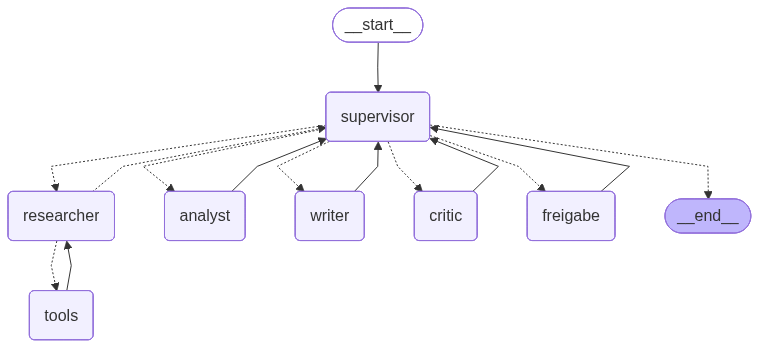

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
import uuid

thema = "KI-Trends im Marketing 2026"

# recursion_limit bewusst erhoehen, da unser eigener
# zyklus_count-Zaehler (MAX_ZYKLEN) jetzt die eigentliche, sauber
# eskalierende Notbremse ist statt eines harten LangGraph-Abbruchs.
# Und Thread-ID setzen, damit diese Notebook-Zelle immer wieder ausgeführt werden kann.
config = {"configurable": {"thread_id": str(uuid.uuid4())}, "recursion_limit": 50}

ergebnis = graph.invoke(
    {
        "messages": [],
        "thema": thema,
        "next": "",
        "instruction": "",
        "recherche": [],
        "analyse": "",
        "bericht": "",
        "verlauf": [],
        "critic_ausreichend": False,
        "critic_feedback": "",
        "critic_grund": "keine",
        "freigabe_feedback": "",
        "researcher_retries": 0,
        "writer_retries": 0,
        "last_critic_feedback": "",
        "last_freigabe_feedback": "",
        "zyklus_count": 0,
        "log": [],
    },
    config=config,
)

# Schleife für Human-in-the-Loop
while "__interrupt__" in ergebnis:
    mensch_input = input("\nEingabe (ok / Feedback): ").strip() or "ok"
    ergebnis = graph.invoke(Command(resume=mensch_input), config=config)

print("\n" + "="*60)
print(f"Verlauf: {' -> '.join(ergebnis['verlauf'])}")
print("FINALER BERICHT")
print("="*60)
print(ergebnis["bericht"])


[Supervisor] -> researcher: Recherchiere gruendlich zum Thema....

[Researcher] Fertig (28617 Zeichen neue Rohdaten)

[Supervisor] -> analyst: Analysiere die Recherche....

[Analyst] Fertig (2969 Zeichen)

[Supervisor] -> writer: Schreibe den Bericht basierend auf der Analyse....

[Writer] Fertig (2251 Zeichen)

[Supervisor] -> critic: Bewerte den Bericht....

[Critic] ausreichend=True, grund=keine

[Supervisor] -> freigabe: Hole die menschliche Freigabe ein....

BERICHT ZUR FREIGABE (Critic: ausreichend=True):
# KI-Trends im Marketing 2026 – Kurzbericht

## Agentic AI: Vom Tool zum autonomen System
Agentic AI ersetzt 2026 die punktuelle KI-Unterstützung durch autonome Agenten, die komplette Marketing-Workflows eigenständig ausführen. Dies markiert einen Paradigmenwechsel: Statt einzelne Aufgaben zu beschleunigen, übernehmen KI-Systeme End-to-End-Prozesse und reduzieren menschliche Entscheidungspunkte dramatisch. Unternehmen müssen sich auf KI-Systeme statt KI-Tools vorbereiten.

## A


Eingabe (ok / Feedback):  Der Bericht soll mit 2-3 Zahlen zum Thema ergänzt werden.



BERICHT ZUR FREIGABE (Critic: ausreichend=True):
# KI-Trends im Marketing 2026 – Kurzbericht

## Agentic AI: Vom Tool zum autonomen System
Agentic AI ersetzt 2026 die punktuelle KI-Unterstützung durch autonome Agenten, die komplette Marketing-Workflows eigenständig ausführen. Dies markiert einen Paradigmenwechsel: Statt einzelne Aufgaben zu beschleunigen, übernehmen KI-Systeme End-to-End-Prozesse und reduzieren menschliche Entscheidungspunkte dramatisch. Unternehmen müssen sich auf KI-Systeme statt KI-Tools vorbereiten.

## Answer Engine Optimization statt SEO
Traditionelle Suchmaschinenoptimierung verliert an Relevanz. Answer Engines wie Perplexity und ChatGPT verändern die Content-Discovery fundamental. Websites, die für klassische Keywords optimiert sind, werden für KI-Suchmaschinen 2026 „unsichtbar". Unternehmen müssen ihre Content-Strategie von Keyword-Fokus auf direkte Antwort-Strukturierung umstellen – eine strategische Notwendigkeit, nicht optional.

## Hyper-Personalisierung 


Eingabe (ok / Feedback):  Dezimalzahlen sollen mit Punkt statt Komma geschrieben werden (z.B. 11.58 statt 11,58).



BERICHT ZUR FREIGABE (Critic: ausreichend=True):
# KI-Trends im Marketing 2026 – Kurzbericht

## Agentic AI: Vom Tool zum autonomen Partner
Bis 2026 werden 40% der Enterprise-Anwendungen Task-spezifische KI-Agenten nutzen. Diese autonomen Systeme orchestrieren End-to-End-Marketing-Workflows intelligent und markieren den Übergang von reaktiven Tools zu proaktiven Agenten. Damit einher geht eine fundamentale Verschiebung: Marketer werden von Executoren zu Orchestratoren.

## Answer Engine Optimization statt klassische SEO
Die Suchlandschaft transformiert sich radikal. KI-gestützte Suchmaschinen wie Perplexity und ChatGPT ersetzen Google als dominante Plattformen – Websites, die 2016 für Google optimiert sind, werden 2026 unsichtbar. Content-Strategien müssen sich von Keyword-Ranking auf direkte Antworten und Kontextrelevanz ausrichten.

## Hyper-Personalisierung als neuer Standard
80% der Unternehmen nutzen generative KI im Marketing. Echtzeit-Personalisierung ist nicht mehr optional – 


Eingabe (ok / Feedback):  ok



BERICHT ZUR FREIGABE (Critic: ausreichend=True):
# KI-Trends im Marketing 2026 – Kurzbericht

## Agentic AI als neues Paradigma
40% der Enterprise-Anwendungen werden bis 2026 Task-spezifische KI-Agenten nutzen. Der Paradigmenwechsel führt von reaktiven Tools zu proaktiven, autonomen Agenten – eine fundamentale Verschiebung von Execution zu intelligenter Orchestrierung mit menschlicher Kontrolle.

## Answer Engine Optimization statt klassischer SEO
AEO ersetzt Google-SEO als Wettbewerbseinheit. Websites, die 2016 für Google optimiert wurden, sind 2026 für moderne KI-Suchmaschinen (Perplexity, ChatGPT, Google) unsichtbar. Content-Strategie muss sich von Keyword-Ranking zu direkten Antworten und Kontextrelevanz verschieben.

## Hyper-Personalisierung wird Standard
80% der Unternehmen setzen auf generative KI im Marketing. Echtzeit-Personalisierung ist nicht mehr optional – generische Kampagnen wirken austauschbar. Multi-Touch Attribution mit KI verbessert die Conversion-Zuordnung um durc

In [11]:
log = ergebnis["log"]
for eintrag in log:
    if eintrag['knoten'] == 'researcher':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('recherche:', eintrag['recherche'], '\n')
        print('basierend_auf_feedback:', eintrag['basierend_auf_feedback'], '\n')

[1] knoten: researcher 

recherche: Titel: The Future of Marketing: 5 Trends and Predictions for 2026 - Gartner
URL: https://www.gartner.com/en/articles/future-of-marketing
Auszug: The latest trends in marketing include AI‑powered personalization, rising creator influence, short‑form video dominance, social commerce growth, and a shift ...

Titel: Adobe AI and Digital Trends 2026: GenAI and Agentic AI Insights
URL: https://business.adobe.com/resources/digital-trends-report.html
Auszug: This year's AI and Digital Trends report highlights the promise and pressure of this shift, the critical gaps holding brands back, and what it takes to deliver ...

Titel: 2026 State of Marketing Report - HubSpot
URL: https://www.hubspot.com/state-of-marketing
Auszug: The 2026 State of Marketing Report · Marketing's Once-in-a-Generation Shift. 61%. 61% of marketers believe that marketing is experiencing its biggest disruption ...

Titel: 34 AI in Marketing Statistics: Industry Trends in 2026 - Shopify
UR

In [12]:
for eintrag in log:
    if eintrag['knoten'] == 'analyst':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('analyse:', eintrag['analyse'], '\n')

[2] knoten: analyst 

analyse: # Analyse: KI-Trends im Marketing 2026

## 1. **Agentic AI als Paradigmenwechsel**
**Kernfakten:**
- Agentic AI (autonome KI-Agenten) etabliert sich als dominanter Trend neben generativer KI
- McKinsey und Adweek identifizieren Agentic Workflows als Schlüssel für Kampagnenbeschleunigung und Personalisierung in Echtzeit
- Unterschied zu bisheriger KI: Agenten führen eigenständig End-to-End-Marketing-Workflows aus statt nur einzelne Aufgaben zu unterstützen
- **Praktische Implikation:** Shift von KI-Tools zu KI-Systemen, die menschliche Entscheidungen reduzieren und Geschwindigkeit erhöhen

## 2. **Answer Engine Optimization (AEO) ersetzt SEO-Fokus**
**Kernfakten:**
- AEO wird zur neuen Wettbewerbseinheit (nicht mehr Keywords, sondern direkte Antworten)
- Websites, die für Google 2016 optimiert sind, werden 2026 "unsichtbar" für KI-Suchmaschinen
- Perplexity, ChatGPT und andere Answer Engines verändern die Content-Discovery fundamental
- **Geschäftsimplikat

In [13]:
for eintrag in log:
    if eintrag['knoten'] == 'writer':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('bericht:', eintrag['bericht'], '\n')
        print('basierend_auf_feedback:', eintrag['basierend_auf_feedback'], '\n')

[3] knoten: writer 

bericht: # KI-Trends im Marketing 2026 – Kurzbericht

## Agentic AI: Vom Tool zum autonomen System
Agentic AI ersetzt 2026 die punktuelle KI-Unterstützung durch autonome Agenten, die komplette Marketing-Workflows eigenständig ausführen. Dies markiert einen Paradigmenwechsel: Statt einzelne Aufgaben zu beschleunigen, übernehmen KI-Systeme End-to-End-Prozesse und reduzieren menschliche Entscheidungspunkte dramatisch. Unternehmen müssen sich auf KI-Systeme statt KI-Tools vorbereiten.

## Answer Engine Optimization statt SEO
Traditionelle Suchmaschinenoptimierung verliert an Relevanz. Answer Engines wie Perplexity und ChatGPT verändern die Content-Discovery fundamental. Websites, die für klassische Keywords optimiert sind, werden für KI-Suchmaschinen 2026 „unsichtbar". Unternehmen müssen ihre Content-Strategie von Keyword-Fokus auf direkte Antwort-Strukturierung umstellen – eine strategische Notwendigkeit, nicht optional.

## Hyper-Personalisierung wird zur Baseline
80

In [14]:
for eintrag in log:
    if eintrag['knoten'] == 'critic':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('ausreichend:', eintrag['ausreichend'], '\n')
        print('grund:', eintrag['grund'], '\n')
        print('feedback:', eintrag['feedback'], '\n')

[4] knoten: critic 

ausreichend: True 

grund: keine 

feedback:  

[9] knoten: critic 

ausreichend: True 

grund: keine 

feedback:  

[12] knoten: critic 

ausreichend: True 

grund: keine 

feedback:  



In [15]:
for eintrag in log:
    if eintrag['knoten'] == 'freigabe':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('feedback:', eintrag['feedback'], '\n')

[5] knoten: freigabe 

feedback: Der Bericht soll mit 2-3 Zahlen zum Thema ergänzt werden. 

[10] knoten: freigabe 

feedback: Dezimalzahlen sollen mit Punkt statt Komma geschrieben werden (z.B. 11.58 statt 11,58). 

[13] knoten: freigabe 

feedback: ok 

